# Question 4: PCA and K-Means
Dataset: `mobile_price.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

c:\Users\janas\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\janas\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 4a. Load data, split features/labels, standardize with z-score

In [29]:
df = pd.read_csv('mobile_price.csv')

X = df.drop(columns=['price_range'])
y = df['price_range']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Mean: {X_scaled.mean(axis=0).round(6)}')
print(f'Std: {X_scaled.std(axis=0).round(6)}')

Mean: [ 0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0.  0. -0.  0.  0.
 -0.  0.]
Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4b. PCA: project to 2D and visualize

Explained variance ratio: PC1=0.0839, PC2=0.0811
Total variance explained: 0.1650


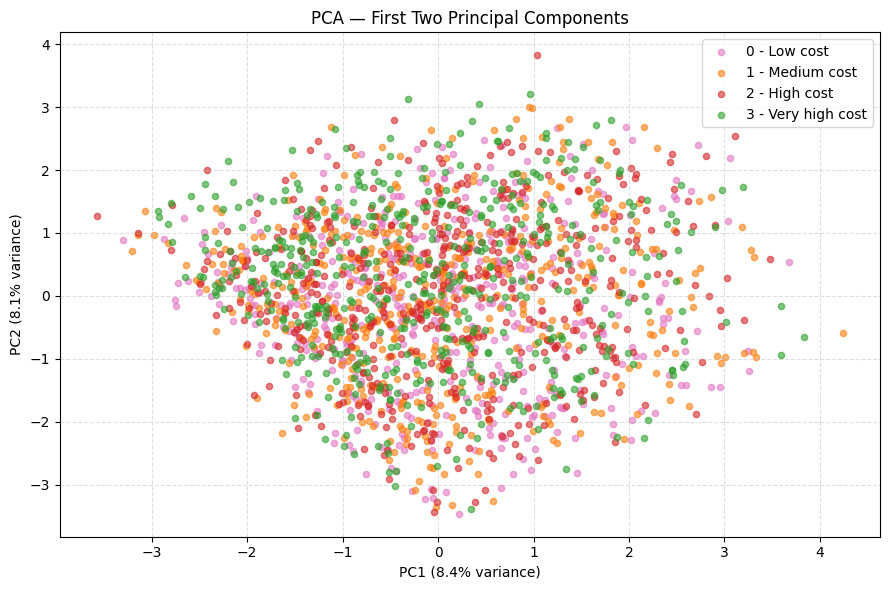

In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.4f}, '
      f'PC2={pca.explained_variance_ratio_[1]:.4f}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.4f}')

colors = ['#e377c2', '#ff7f0e', '#d62728', '#2ca02c']
labels_names = ['0 - Low cost', '1 - Medium cost', '2 - High cost', '3 - Very high cost']

fig, ax = plt.subplots(figsize=(9, 6))
for cls in range(4):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=labels_names[cls],
               alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA — First Two Principal Components')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('q4b_pca.png', dpi=150)
plt.show()

## 4c. K-Means on all features (20D), visualize via PCA 2D projection

K-Means (all features) — Adjusted Rand Score: 0.0060


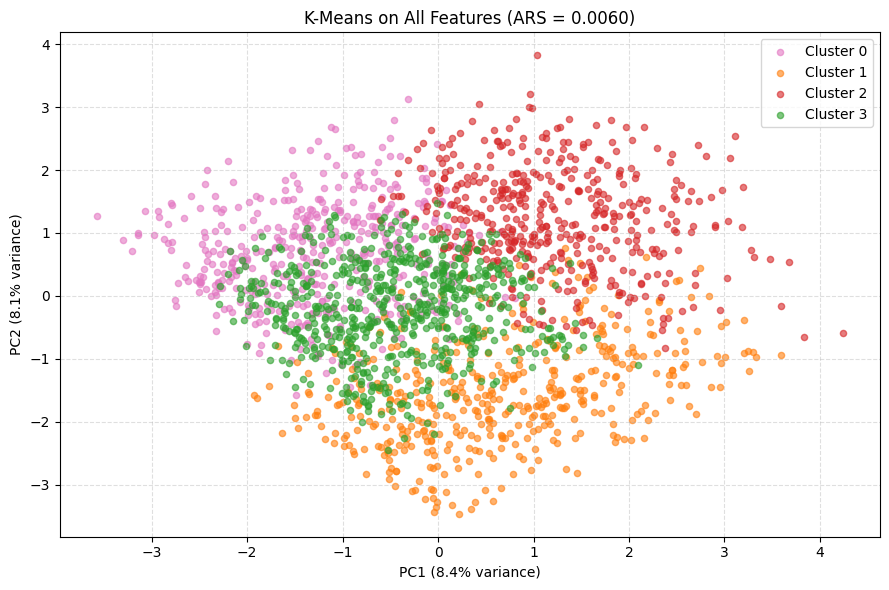

In [24]:
kmeans_all = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_all = kmeans_all.fit_predict(X_scaled)

ars_all = adjusted_rand_score(y, cluster_labels_all)
print(f'K-Means (all features) — Adjusted Rand Score: {ars_all:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
for cluster in range(4):
    mask = cluster_labels_all == cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cluster], label=f'Cluster {cluster}',
               alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means on All Features')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('q4c_kmeans_all.png', dpi=150)
plt.show()

## 4d. K-Means on 2D PCA features

K-Means (PCA 2D features) — Adjusted Rand Score: 0.0017


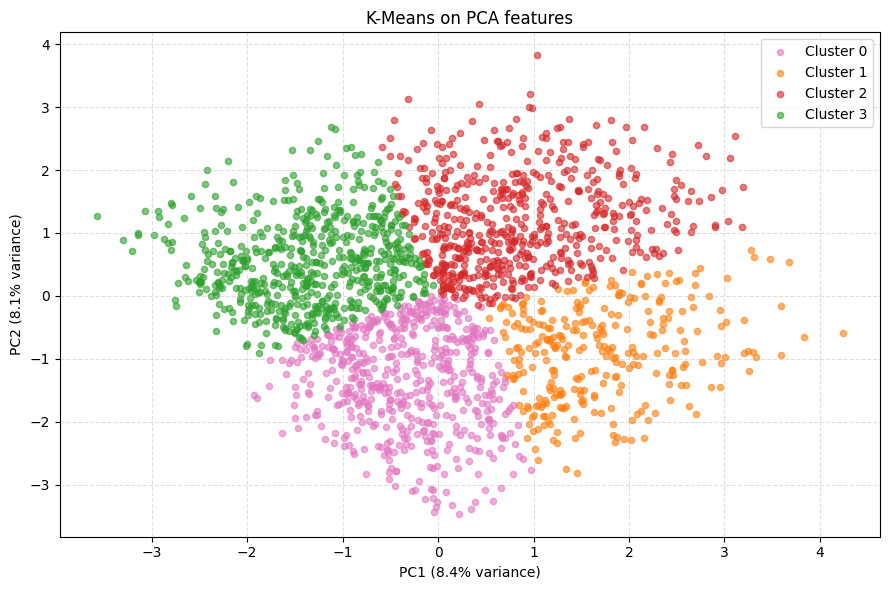

In [25]:
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels_pca = kmeans_pca.fit_predict(X_pca)

ars_pca = adjusted_rand_score(y, cluster_labels_pca)
print(f'K-Means (PCA 2D features) — Adjusted Rand Score: {ars_pca:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
for cluster in range(4):
    mask = cluster_labels_pca == cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cluster], label=f'Cluster {cluster}',
               alpha=0.6, s=20)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means on PCA features')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('q4d_kmeans_pca.png', dpi=150)
plt.show()

## Summary: ARS Comparison

In [26]:
print('=' * 45)
print(f'  K-Means on all features  | ARS = {ars_all:.4f}')
print(f'  K-Means on PCA 2D        | ARS = {ars_pca:.4f}')
print('=' * 45)

  K-Means on all features  | ARS = 0.0060
  K-Means on PCA 2D        | ARS = 0.0017
